<a href="https://colab.research.google.com/github/zisuzhao001/sea_level/blob/main/src/sl_ellen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sea Level Project**

In [ ]:
import sys
import sklearn
from packaging import version

print("Welcome to the Ocean!")
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
assert sys.version_info >= (3, 7)

from google.colab import drive
drive.mount('/content/drive')


Welcome to the Ocean!


# Get the Data

In [ ]:
import os, sys
import pandas as pd
import tarfile
import urllib.request

def in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False

def data_dir() -> str:
    if in_colab():
        # default Colab path after mounting Drive
        return "/content/drive/MyDrive/Data"
    return os.path.abspath("./data")  # local default

def path(*parts) -> str:
    return os.path.join(data_dir(), *parts)

def load_data():
    filename="sl_raw.csv"
    return pd.read_csv(path(filename))

_rawdata = load_data()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Take a Quick Look at the Data Structure

In [ ]:
#rawdata.head()
_rawdata.info()
_rawdata.describe()
#rawdata["Sea Level Monthly Mean"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            275 non-null    object 
 1   Sea Level Monthly Mean          275 non-null    float64
 2   Antarctic Ice Melt Rates(mass)  245 non-null    float64
 3   Greenland Ice Melt Rates(mass)  245 non-null    float64
 4   Global Temp Anomaly             275 non-null    float64
 5   El Nino                         275 non-null    float64
dtypes: float64(5), object(1)
memory usage: 13.0+ KB


,Sea Level Monthly Mean,Antarctic Ice Melt Rates(mass),Greenland Ice Melt Rates(mass),Global Temp Anomaly,El Nino
count,275.000000,245.000000,245.000000,275.00000,275.000000
mean,0.083360,-1292.686367,-2922.423347,0.80120,-0.015345
std,0.073657,944.208187,1824.862624,0.23591,0.833516
min,-0.166000,-2780.900000,-5608.870000,0.26000,-1.640000
25%,0.037500,-2274.680000,-4754.780000,0.63000,-0.610000
50%,0.078000,-1145.840000,-3216.520000,0.76000,-0.110000
75%,0.129500,-398.130000,-1272.280000,0.92000,0.485000
max,0.295000,82.680000,69.380000,1.48000,2.640000


The following cell is not shown either in the book. It creates the `images` folder (if it doesn't already exist), and it defines the `save_fig()` function which is used through this notebook to save the figures in high-res for the book.

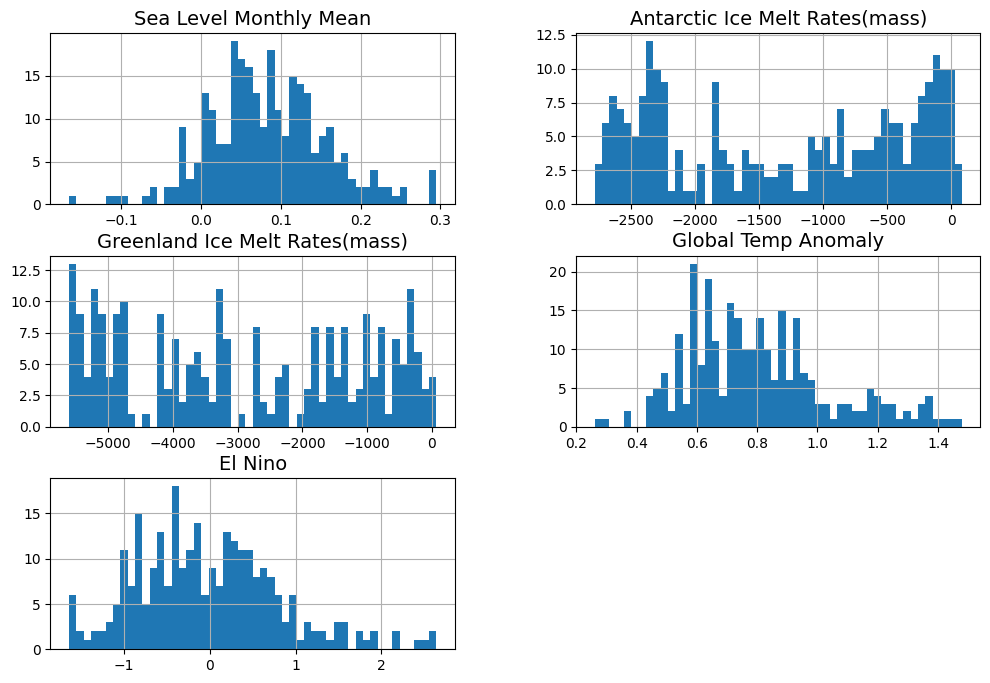

In [ ]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

_rawdata.hist(bins=50, figsize=(12, 8))
#save_fig("attribute_histogram_plots")  # extra code
plt.show()

## Looking for Correlations

Note: since Pandas 2.0.0, the `numeric_only` argument defaults to `False`, so we need to set it explicitly to True to avoid an error.

In [ ]:
corr_matrix = _rawdata.corr(numeric_only=True)
corr_matrix["Sea Level Monthly Mean"].sort_values(ascending=False)

Sea Level Monthly Mean            1.000000
Global Temp Anomaly               0.487193
El Nino                           0.156084
Antarctic Ice Melt Rates(mass)   -0.533573
Greenland Ice Melt Rates(mass)   -0.579407
Name: Sea Level Monthly Mean, dtype: float64

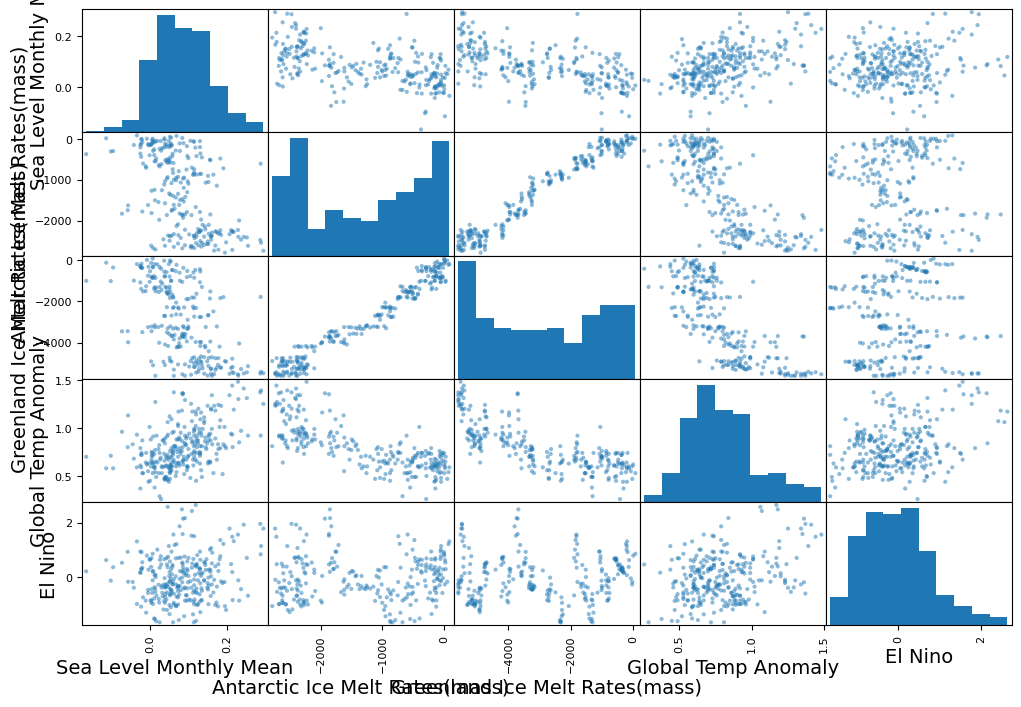

In [ ]:
from pandas.plotting import scatter_matrix

attributes = ["Sea Level Monthly Mean","Antarctic Ice Melt Rates(mass)","Greenland Ice Melt Rates(mass)","Global Temp Anomaly",	"El Nino"]
scatter_matrix(_rawdata[attributes], figsize=(12, 8))
#save_fig("scatter_matrix_plot")  # extra code
plt.show()

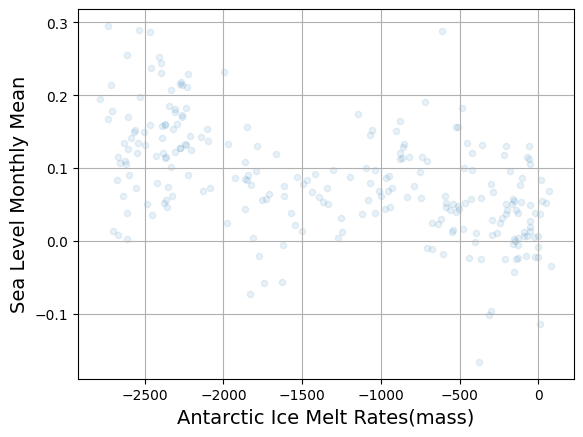

In [ ]:
_rawdata.plot(kind="scatter", x="Antarctic Ice Melt Rates(mass)", y="Sea Level Monthly Mean",
             alpha=0.1, grid=True)
#save_fig("income_vs_house_value_scatterplot")  # extra code
plt.show()


## Create Test Set

In [ ]:
from sklearn.model_selection import train_test_split
data_num = _rawdata.drop("Date", axis=1) # remove Date column for tranning
train_set, test_set = train_test_split(data_num, test_size=0.2, random_state=42)

rawdata = train_set.drop("Sea Level Monthly Mean", axis=1)
rawdata_labels = train_set["Sea Level Monthly Mean"].copy()

In [ ]:
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 220 entries, 10 to 102
Data columns (total 4 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Antarctic Ice Melt Rates(mass)  196 non-null    float64
 1   Greenland Ice Melt Rates(mass)  197 non-null    float64
 2   Global Temp Anomaly             220 non-null    float64
 3   El Nino                         220 non-null    float64
dtypes: float64(4)
memory usage: 8.6 KB


## Data Cleaning

In [ ]:
null_rows_idx = rawdata.isnull().any(axis=1)
rawdata.loc[null_rows_idx].head()

,Antarctic Ice Melt Rates(mass),Greenland Ice Melt Rates(mass),Global Temp Anomaly,El Nino
147,NaN,NaN,0.80,0.49
194,NaN,NaN,0.80,0.49
112,NaN,NaN,0.59,-1.09
159,NaN,NaN,1.07,2.42
111,NaN,NaN,0.65,-1.01


In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np

data_num = rawdata.select_dtypes(include=[np.number])
imputer = SimpleImputer(strategy="median")
imputer.fit(data_num)
imputer.statistics_
data_num.median().values

array([-1.106975e+03, -3.216520e+03,  7.800000e-01, -1.150000e-01])

Transform the training set:

In [ ]:
X = imputer.transform(data_num)
data_tr = pd.DataFrame(X, columns=data_num.columns,
                          index=data_num.index)
data_tr.loc[null_rows_idx].head()

,Antarctic Ice Melt Rates(mass),Greenland Ice Melt Rates(mass),Global Temp Anomaly,El Nino
147,-1106.975,-3216.52,0.80,0.49
194,-1106.975,-3216.52,0.80,0.49
112,-1106.975,-3216.52,0.59,-1.09
159,-1106.975,-3216.52,1.07,2.42
111,-1106.975,-3216.52,0.65,-1.01


## Transformation Pipelines

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    #("impute", SimpleImputer(strategy="median")),
    ("impute", KNNImputer(n_neighbors=2, weights="distance")),
    ("standardize", StandardScaler()),
])

num_pipeline.steps

[('impute', KNNImputer(n_neighbors=2, weights='distance')),
 ('standardize', StandardScaler())]

In [ ]:
from sklearn.pipeline import FunctionTransformer, make_pipeline
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

# Robust converter: accepts DataFrame, Series or ndarray and returns 2D numpy array
def column_date_yyyymmdd(X):
    # Handle pandas DataFrame / Series or numpy array-like
    if isinstance(X, pd.DataFrame):
        col = X.iloc[:, 0]
    elif isinstance(X, pd.Series):
        col = X
    else:
        arr = np.asarray(X)
        if arr.ndim == 1:
            col = pd.Series(arr)
        else:
            col = pd.Series(arr[:, 0])

    # Parse to datetime (coerce invalid values), format, preserve missing as <NA>
    col = pd.to_datetime(col, errors='coerce', utc=True)
    col_yyyymmdd = col.dt.strftime('%Y%m%d').where(col.notna())

    # Return a 2D numpy array (n_samples, 1); use to_numpy() to avoid object dtype
    return col_yyyymmdd.astype('Int64').to_numpy().reshape(-1, 1)

# Callable for feature names — accept any args sklearn may pass
def get_feature_names(*args, **kwargs):
    return ['date_yyyymmdd']

# Pipeline for date column — pass validate=False so we get pandas objects
date_pipeline = make_pipeline(
    FunctionTransformer(column_date_yyyymmdd, validate=False, feature_names_out=get_feature_names),
)

# Default numeric pipeline
default_num_pipeline = make_pipeline(KNNImputer(n_neighbors=2, weights='distance'),
                                     StandardScaler())

preprocessing = ColumnTransformer([], remainder=default_num_pipeline)

preprocessing1 = ColumnTransformer([
        ('date', date_pipeline, ['Date']),
    ], remainder=default_num_pipeline)


In [ ]:
rawdata.info()


<class 'pandas.core.frame.DataFrame'>
Index: 220 entries, 10 to 102
Data columns (total 4 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Antarctic Ice Melt Rates(mass)  196 non-null    float64
 1   Greenland Ice Melt Rates(mass)  197 non-null    float64
 2   Global Temp Anomaly             220 non-null    float64
 3   El Nino                         220 non-null    float64
dtypes: float64(4)
memory usage: 8.6 KB


In [ ]:
sl_data = preprocessing.fit_transform(rawdata)
sl_data.shape

(220, 4)

In [ ]:
print(sl_data)

[[ 1.43617698  1.65878812 -0.90600544 -0.27964372]
 [-1.34656265 -1.38428212  2.5223365   1.37830173]
 [-1.16636075 -1.49710667  2.30535283 -0.27964372]
 [ 1.18693208  1.40624046 -0.6022283   0.53748654]
 [-1.61208828 -1.09080358  0.00532596 -1.21519865]
 [ 0.34929717  0.6568022  -0.03807077  0.60854134]
 [ 0.65461418  0.65172206  0.1789129   0.4427468 ]
 [ 1.2420966   1.22388832 -0.90600544 -0.13753411]
 [-1.18065417 -1.07674863  0.35249983 -0.45728073]
 [ 1.34064366  1.46230744 -1.20978257  0.4427468 ]
 [-0.33907867 -0.60577464  0.39589656 -0.71781502]
 [-1.00163156 -1.18181266  0.48269003 -0.9783493 ]
 [ 0.82271744  0.92945316 -1.86073357 -1.77179462]
 [-1.20745023 -1.39938992  2.17516263  0.86907562]
 [ 0.46769689  0.3644757  -1.55695644 -1.85469189]
 [ 0.6144856   0.6476069  -0.29845117  1.80463056]
 [ 0.34929717  0.6568022  -0.03807077  0.60854134]
 [-1.19068904 -1.4292942   2.60912997  2.30201419]
 [ 0.76425529  0.81490217 -1.20978257 -0.83623969]
 [ 1.09804864  1.47152835 -0.99

In [ ]:
feature_names = preprocessing.get_feature_names_out()
sl_data_df = pd.DataFrame(sl_data, columns=feature_names)
null_rows_idx = sl_data_df.isnull().any(axis=1)
sl_data_df.loc[null_rows_idx].head()

,remainder__Antarctic Ice Melt Rates(mass),remainder__Greenland Ice Melt Rates(mass),remainder__Global Temp Anomaly,remainder__El Nino


In [ ]:
# Quick inspection: show the first rows of the preprocessed DataFrame
sl_data_df.head()

,remainder__Antarctic Ice Melt Rates(mass),remainder__Greenland Ice Melt Rates(mass),remainder__Global Temp Anomaly,remainder__El Nino
0,1.436177,1.658788,-0.906005,-0.279644
1,-1.346563,-1.384282,2.522337,1.378302
2,-1.166361,-1.497107,2.305353,-0.279644
3,1.186932,1.406240,-0.602228,0.537487
4,-1.612088,-1.090804,0.005326,-1.215199


In [ ]:
# Quick inspection: count missing values per column
sl_data_df.isna().sum()

,0
remainder__Antarctic Ice Melt Rates(mass),0
remainder__Greenland Ice Melt Rates(mass),0
remainder__Global Temp Anomaly,0
remainder__El Nino,0


# Select and Train a Model

## Training and Evaluating on the Training Set

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(rawdata, rawdata_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('knnimputer',
                                                              KNNImputer(n_neighbors=2,
                                                                         weights='distance')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[])),
                ('linearregression', LinearRegression())])

Let's try the full preprocessing pipeline on a few training instances:

In [ ]:
sl_predictions = lin_reg.predict(rawdata)
sl_predictions[:5]  # -2 = rounded to the nearest hundred

array([0.00304167, 0.16491659, 0.1633087 , 0.02499188, 0.06753512])

Compare against the actual values:

In [ ]:
rawdata_labels.iloc[:5].values

array([0.037, 0.289, 0.161, 0.118, 0.195])

In [ ]:
# extra code – computes the error ratios discussed in the book
error_ratios = sl_predictions[:5] / rawdata_labels.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-91.8%, -42.9%, 1.4%, -78.8%, -65.4%


**Warning**: In recent versions of Scikit-Learn, you must use `root_mean_squared_error(labels, predictions)` to compute the RMSE, instead of `mean_squared_error(labels, predictions, squared=False)`. The following `try`/`except` block tries to import `root_mean_squared_error`, and if it fails it just defines it.

In [ ]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

def root_mean_squared_error(labels, predictions):
    return mean_squared_error(labels, predictions, squared=False)

lin_rmse = root_mean_squared_error(rawdata_labels, sl_predictions)
lin_rmse
mae = mean_absolute_error(rawdata_labels,sl_predictions)
print("mae=",mae)

NameError: name 'mean_squared_error' is not defined

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(rawdata, rawdata_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('knnimputer',
                                                              KNNImputer(n_neighbors=2,
                                                                         weights='distance')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [ ]:
housing_predictions = tree_reg.predict(rawdata)
tree_rmse = root_mean_squared_error(rawdata_labels, sl_predictions)
tree_rmse

0.058423456005942564

## Better Evaluation Using Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, rawdata, rawdata_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [ ]:
pd.Series(tree_rmses).describe()

count    10.000000
mean      0.074835
std       0.013226
min       0.052906
25%       0.067133
50%       0.075465
75%       0.083997
max       0.095534
dtype: float64

In [ ]:
# extra code – computes the error stats for the linear model
lin_rmses = -cross_val_score(lin_reg, rawdata, rawdata_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

,0
count,10.000000
mean,0.060936
std,0.014470
min,0.041601
25%,0.056578
50%,0.059134
75%,0.061700
max,0.096154


**Warning:** the following cell may take a few minutes to run:

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, rawdata, rawdata_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [ ]:
pd.Series(forest_rmses).describe()

,0
count,10.000000
mean,0.059644
std,0.012012
min,0.045388
25%,0.050935
50%,0.057157
75%,0.065582
max,0.084365


Let's compare this RMSE measured using cross-validation (the "validation error") with the RMSE measured on the training set (the "training error"):

In [ ]:
forest_reg.fit(rawdata, rawdata_labels)
housing_predictions = forest_reg.predict(rawdata)
forest_rmse = root_mean_squared_error(rawdata_labels, sl_predictions)
forest_rmse

NameError: name 'mean_squared_error' is not defined

The training error is much lower than the validation error, which usually means that the model has overfit the training set. Another possible explanation may be that there's a mismatch between the training data and the validation data, but it's not the case here, since both came from the same dataset that we shuffled and split in two parts.

# Fine-Tune Your Model

## Grid Search

**Warning:** the following cell may take a few minutes to run:

In [ ]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = [
    {'random_forest__max_features': [4, 6, 8]},
    {'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(rawdata, rawdata_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('knnimputer',
                                                                                     KNNImputer(n_neighbors=2,
                                                                                                weights='distance')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'random_forest__max_features': [4, 6, 8]},
                         {'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

You can get the full list of hyperparameters available for tuning by looking at `full_pipeline.get_params().keys()`:

In [ ]:
# extra code – shows part of the output of get_params().keys()
print(str(full_pipeline.get_params().keys())[:1000] + "...")

dict_keys(['memory', 'steps', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__verbose', 'preprocessing__remainder__knnimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__knnimputer__add_indicator', 'preprocessing__remainder__knnimputer__copy', 'preprocessing__remainder__knnimputer__keep_empty_features', 'preprocessing__remainder__knnimputer__metric', 'preprocessing__remainder__knnimputer__missing_values', 'preprocessing__remainder__knnimputer__n_neighbors', 'preprocessing__remainder__knnimputer__weights', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 'preprocessing__transformers', 'preprocessing__verbose', 'preprocessing__verbose

The best hyperparameter combination found:

In [ ]:
grid_search.best_params_

{'random_forest__max_features': 4}

In [ ]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('knnimputer',
                                                              KNNImputer(n_neighbors=2,
                                                                         weights='distance')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[])),
                ('random_forest',
                 RandomForestRegressor(max_features=4, random_state=42))])

Let's look at the score of each hyperparameter combination tested during the grid search:

In [ ]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# extra code – these few lines of code just make the DataFrame look nicer
cv_res = cv_res[["param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].astype(np.int64)

cv_res.head()

,max_features,split0,split1,split2,mean_test_rmse
0,4,0,0,0,0
1,6,0,0,0,0
2,8,0,0,0,0
3,6,0,0,0,0
4,8,0,0,0,0


## Randomized Search

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

Try 30 (`n_iter` × `cv`) random combinations of hyperparameters:

**Warning:** the following cell may take a few minutes to run:

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)

rnd_search.fit(rawdata, rawdata_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('knnimputer',
                                                                                           KNNImputer(n_neighbors=2,
                                                                                                      weights='distance')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x1257aad60>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
# extra code – displays the random search results
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res.columns = [ "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].astype(np.int64)
cv_res.head()

,max_features,split0,split1,split2,mean_test_rmse
0,8,0,0,0,0
1,16,0,0,0,0
2,12,0,0,0,0
3,9,0,0,0,0
4,8,0,0,0,0


**Bonus section: how to choose the sampling distribution for a hyperparameter**

* `scipy.stats.randint(a, b+1)`: for hyperparameters with _discrete_ values that range from a to b, and all values in that range seem equally likely.
* `scipy.stats.uniform(a, b)`: this is very similar, but for _continuous_ hyperparameters.
* `scipy.stats.geom(1 / scale)`: for discrete values, when you want to sample roughly in a given scale. E.g., with scale=1000 most samples will be in this ballpark, but ~10% of all samples will be <100 and ~10% will be >2300.
* `scipy.stats.expon(scale)`: this is the continuous equivalent of `geom`. Just set `scale` to the most likely value.
* `scipy.stats.loguniform(a, b)`: when you have almost no idea what the optimal hyperparameter value's scale is. If you set a=0.01 and b=100, then you're just as likely to sample a value between 0.01 and 0.1 as a value between 10 and 100.


Here are plots of the probability mass functions (for discrete variables), and probability density functions (for continuous variables) for `randint()`, `uniform()`, `geom()` and `expon()`:

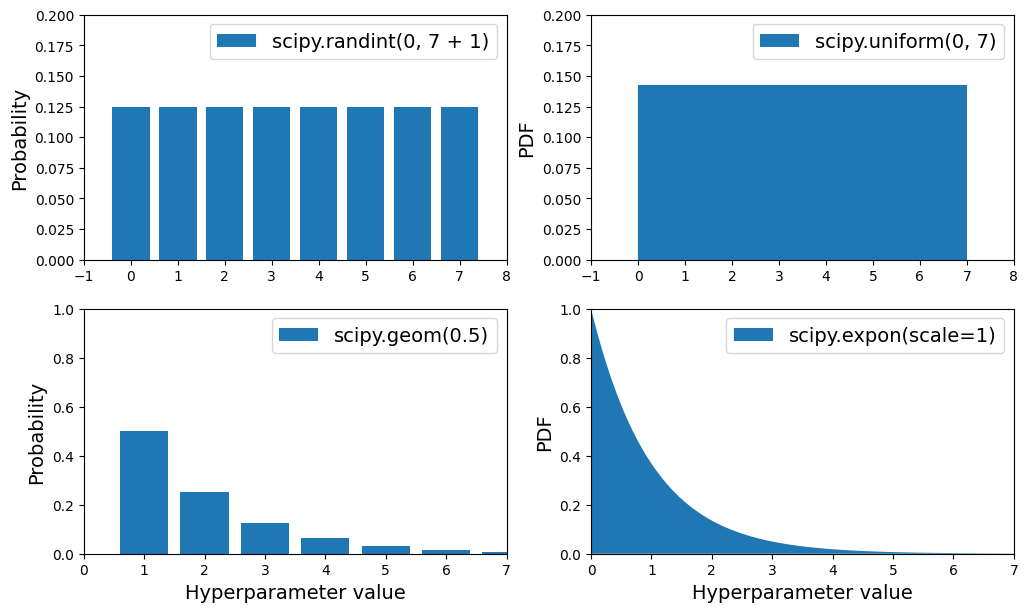

In [ ]:
# extra code – plots a few distributions you can use in randomized search

from scipy.stats import randint, uniform, geom, expon

xs1 = np.arange(0, 7 + 1)
randint_distrib = randint(0, 7 + 1).pmf(xs1)

xs2 = np.linspace(0, 7, 500)
uniform_distrib = uniform(0, 7).pdf(xs2)

xs3 = np.arange(0, 7 + 1)
geom_distrib = geom(0.5).pmf(xs3)

xs4 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.bar(xs1, randint_distrib, label="scipy.randint(0, 7 + 1)")
plt.ylabel("Probability")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 2)
plt.fill_between(xs2, uniform_distrib, label="scipy.uniform(0, 7)")
plt.ylabel("PDF")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 3)
plt.bar(xs3, geom_distrib, label="scipy.geom(0.5)")
plt.xlabel("Hyperparameter value")
plt.ylabel("Probability")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 4)
plt.fill_between(xs4, expon_distrib, label="scipy.expon(scale=1)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.show()

Here are the PDF for `expon()` and `loguniform()` (left column), as well as the PDF of log(X) (right column). The right column shows the distribution of hyperparameter _scales_. You can see that `expon()` favors hyperparameters with roughly the desired scale, with a longer tail towards the smaller scales. But `loguniform()` does not favor any scale, they are all equally likely:

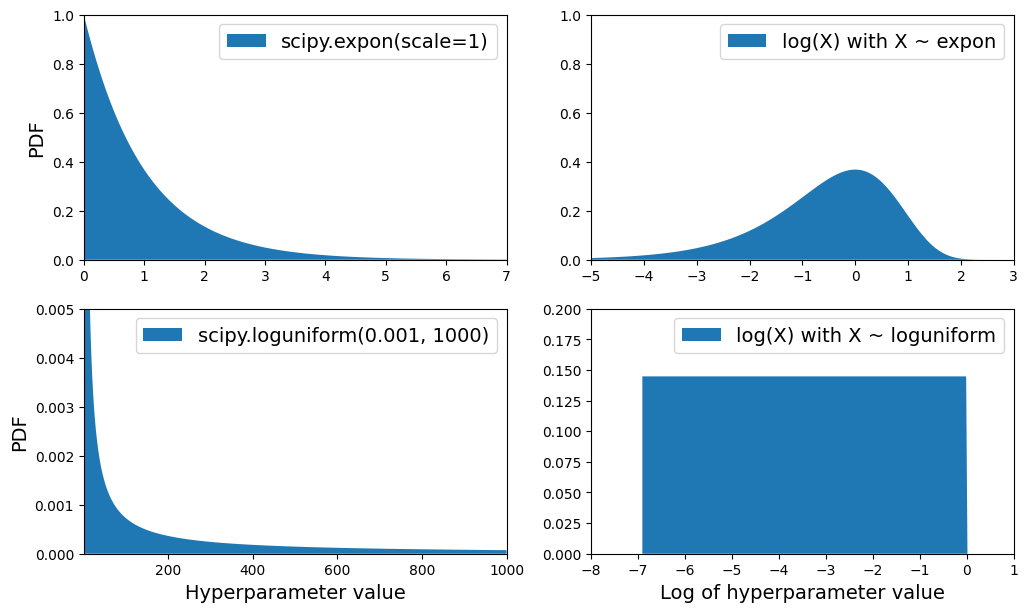

In [ ]:
# extra code – shows the difference between expon and loguniform

from scipy.stats import loguniform

xs1 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs1)

log_xs2 = np.linspace(-5, 3, 500)
log_expon_distrib = np.exp(log_xs2 - np.exp(log_xs2))

xs3 = np.linspace(0.001, 1000, 500)
loguniform_distrib = loguniform(0.001, 1000).pdf(xs3)

log_xs4 = np.linspace(np.log(0.001), np.log(1000), 500)
log_loguniform_distrib = uniform(np.log(0.001), np.log(1000)).pdf(log_xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.fill_between(xs1, expon_distrib,
                 label="scipy.expon(scale=1)")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 2)
plt.fill_between(log_xs2, log_expon_distrib,
                 label="log(X) with X ~ expon")
plt.legend()
plt.axis([-5, 3, 0, 1])

plt.subplot(2, 2, 3)
plt.fill_between(xs3, loguniform_distrib,
                 label="scipy.loguniform(0.001, 1000)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0.001, 1000, 0, 0.005])

plt.subplot(2, 2, 4)
plt.fill_between(log_xs4, log_loguniform_distrib,
                 label="log(X) with X ~ loguniform")
plt.xlabel("Log of hyperparameter value")
plt.legend()
plt.axis([-8, 1, 0, 0.2])

plt.show()

## Analyze the Best Models and Their Errors

In [ ]:
final_model = rnd_search.best_estimator_  # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.23, 0.47, 0.13, 0.17])

In [ ]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
           reverse=True)

[(0.47391174094952565, 'remainder__Greenland Ice Melt Rates(mass)'),
 (0.22864178756683745, 'remainder__Antarctic Ice Melt Rates(mass)'),
 (0.16981761355598304, 'remainder__El Nino'),
 (0.1276288579276539, 'remainder__Global Temp Anomaly')]

## Evaluate Your System on the Test Set

In [ ]:
X_test = test_set.drop("Sea Level Monthly Mean", axis=1)
y_test = test_set["Sea Level Monthly Mean"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

0.05594610790579222


In [ ]:
print(final_predictions)

[ 0.02943     0.07115     0.09375     0.09034     0.24578     0.06959
  0.08871     0.10938     0.254       0.08625     0.03324     0.13611
  0.07709     0.08291     0.15723     0.06202     0.11833833  0.04061
  0.11075     0.16325     0.0401      0.05084     0.12189     0.049
  0.14898     0.12704     0.06924     0.03906    -0.00347     0.09788167
  0.00371     0.05078     0.07731     0.07312     0.0924      0.0464625
  0.0543      0.16885     0.01672     0.01567     0.0532      0.12186
  0.04524     0.06511     0.04802     0.13044    -0.01886     0.08215
  0.2084      0.09411     0.10232417  0.02632     0.20623     0.03044
  0.07206    -0.02322   ]


We can compute a 95% confidence interval for the test RMSE:

In [ ]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
                              confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval


In [ ]:
rmse_lower, rmse_upper

(39574.03054635233, 43779.833703193224)